# 01 — LendingClub profiling: consumers & leads

Fits `docs/calibration_spec.md` Section 1 and writes `simulation/params/lendingclub_marginals.json`.
The simulator reads only that JSON (decision A1) — this notebook is the only code that touches the raw files.

Provenance: A — agent-built per the calibration spec; assumptions cite decision ids (C-series).

**Sources** (`data/raw/lendingclub/`, git-ignored): `accepted_2007_to_2018Q4.csv.gz` (funded loans, 151 cols)
and `rejected_2007_to_2018Q4.csv.gz` (declined applications, 9 cols). Per decision C8, the copula and most
marginals are fitted on *accepted* (only it has the rich features); *rejected* is used to (a) widen the
`loan_amnt`/`dti` tails toward the true applicant population and (b) fit the acceptance model whose score
becomes the lead quality score `q`.

**QA gates (spec Section 1, thresholds per C4):** KS < 0.05 per numeric marginal; categorical mixes within
±1pp; copula max absolute correlation error < 0.1; simulated `q` distribution visually matches the
accept-score histogram. The notebook raises if a hard gate fails.


In [1]:
# Configuration and reproducibility: one seed drives every sampling step.
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

SEED = 42
rng = np.random.default_rng(SEED)

ROOT = Path.cwd().resolve().parents[1]
assert (ROOT / "pyproject.toml").exists(), f"unexpected notebook cwd: {Path.cwd()}"
RAW = ROOT / "data" / "raw" / "lendingclub"
PARAMS_PATH = ROOT / "simulation" / "params" / "lendingclub_marginals.json"

N_QUANTILES = 1000          # inverse-CDF lookup resolution (spec Section 1)
POOL_TARGET = 3_000_000     # pooled applicant-population sample size for tail-widening
SIM_N = 200_000             # draws used by the QA gates
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Data-mutation ledger: every operation that alters data (row drops, sentinel
# handling, winsorization clips, recategorization, imputation) is recorded here,
# displayed before the params are written, and embedded in the params metadata.
MUTATIONS = []
def record_mutation(step, column, rows, disposition, rationale):
    MUTATIONS.append({"step": step, "column": column, "rows_affected": int(rows),
                      "disposition": disposition, "rationale": rationale})
    print(f"[mutation] {step} / {column}: {rows:,} rows — {disposition}")

print(f"repo root: {ROOT}")


repo root: /Users/jordanbeary/tributary


## 1. Load

Rejected-file column mapping (documented per the spec's rejected-loans note):

| Rejected column | Accepted equivalent | Note |
| --- | --- | --- |
| `Amount Requested` | `loan_amnt` | |
| `Debt-To-Income Ratio` | `dti` | string with `%` suffix, stripped |
| `Employment Length` | `emp_length` | same bucket labels |
| `State` | `addr_state` | |
| `Risk_Score` | (no clean equivalent) | not used — FICO exists only on accepted |


In [2]:
# Accepted: full read of the 8 needed columns (~2.3M rows).
ACC_COLS = ["loan_amnt", "purpose", "emp_length", "dti",
            "fico_range_low", "fico_range_high", "addr_state", "annual_inc"]
acc = pd.read_csv(RAW / "accepted_2007_to_2018Q4.csv.gz", usecols=ACC_COLS)
# The file ends with non-data summary trailer lines; they coerce to NaN on loan_amnt.
n_raw = len(acc)
acc = acc.dropna(subset=["loan_amnt"])
record_mutation("load accepted", "loan_amnt", n_raw - len(acc),
                "rows dropped", "file trailer summary lines, not loan records")
print(f"accepted rows: {len(acc):,}")
acc.head(3)


[mutation] load accepted / loan_amnt: 33 rows — rows dropped
accepted rows: 2,260,668


,loan_amnt,emp_length,annual_inc,purpose,addr_state,dti,fico_range_low,fico_range_high
0,"3,600.000",10+ years,"55,000.000",debt_consolidation,PA,5.910,675.000,679.000
1,"24,700.000",10+ years,"65,000.000",small_business,SD,16.060,715.000,719.000
2,"20,000.000",10+ years,"63,000.000",home_improvement,IL,10.780,695.000,699.000


In [3]:
# Rejected: ~27M rows, so stream in chunks, keep a seeded uniform subsample,
# and count the full population for the true acceptance rate.
REJ_USECOLS = ["Amount Requested", "Debt-To-Income Ratio", "State", "Employment Length"]
REJ_RENAME = {"Amount Requested": "loan_amnt", "Debt-To-Income Ratio": "dti",
              "State": "addr_state", "Employment Length": "emp_length"}
KEEP_FRAC = 0.15  # ~4M kept of ~27M — plenty for 1000-point quantiles

rej_parts, n_rej_total, n_neg_dti = [], 0, 0
reader = pd.read_csv(RAW / "rejected_2007_to_2018Q4.csv.gz",
                     usecols=REJ_USECOLS, chunksize=2_000_000)
for chunk in reader:
    n_rej_total += len(chunk)
    part = chunk.sample(frac=KEEP_FRAC, random_state=SEED).rename(columns=REJ_RENAME)
    # dti arrives as a percent-string ("10.5%"); coerce to float. Negative values
    # are the rejected file's missing-DTI sentinel (-1%), not real ratios.
    part["dti"] = pd.to_numeric(part["dti"].astype(str).str.rstrip("%"), errors="coerce")
    n_neg_dti += int((part["dti"] < 0).sum())
    part.loc[part["dti"] < 0, "dti"] = np.nan
    rej_parts.append(part)
rej = pd.concat(rej_parts, ignore_index=True)
del rej_parts
record_mutation("load rejected", "dti", n_neg_dti, "set NaN (sentinel)",
                "negative percent values are the rejected file's missing-DTI sentinel")

acceptance_rate = len(acc) / (len(acc) + n_rej_total)
print(f"rejected rows: {n_rej_total:,} (sampled {len(rej):,})")
print(f"true acceptance rate: {acceptance_rate:.4f}")


[mutation] load rejected / dti: 180,354 rows — set NaN (sentinel)
rejected rows: 27,648,741 (sampled 4,147,311)
true acceptance rate: 0.0756


## 2. Clean and derive

- `fico_mid` = midpoint of the accepted FICO range columns.
- `emp_length` maps to ordinal years for the copula and the acceptance model; the
  categorical mix keeps an explicit `n/a` bucket (missingness is real applicant behavior).
- Winsorization per spec: `dti` at 1%/99% (on the pooled applicant population),
  `annual_inc` at 1%/99% in log space (accepted only). Bounds are stored in the params
  so the simulator clips identically. Negative rejected-file DTIs are treated as the
  missing-value sentinel they are (not winsorized into the distribution).


In [4]:
EMP_ORDER = ["< 1 year", "1 year", "2 years", "3 years", "4 years", "5 years",
             "6 years", "7 years", "8 years", "9 years", "10+ years", "n/a"]
EMP_YEARS = {"< 1 year": 0.5, "1 year": 1, "2 years": 2, "3 years": 3, "4 years": 4,
             "5 years": 5, "6 years": 6, "7 years": 7, "8 years": 8, "9 years": 9,
             "10+ years": 10}

n_emp_na = int(acc["emp_length"].isna().sum() + rej["emp_length"].isna().sum())
for df in (acc, rej):
    df["emp_length"] = df["emp_length"].fillna("n/a")
    df["emp_years"] = df["emp_length"].map(EMP_YEARS)  # NaN for the n/a bucket
record_mutation("clean", "emp_length", n_emp_na, "recategorized to 'n/a' bucket",
                "missingness is real applicant behavior; kept in the categorical mix, "
                "excluded from the copula, imputed (with indicator) in the acceptance model")

# Accepted dti = 999 is a hard sentinel: 135 rows sit at exactly 999 and none above.
# The genuine heavy tail (values in 100-999, mostly joint applications) is left for
# winsorization to handle.
n_dti999 = int((acc["dti"] >= 999).sum())
acc.loc[acc["dti"] >= 999, "dti"] = np.nan
record_mutation("clean", "dti (accepted)", n_dti999, "set NaN (sentinel)",
                "dti == 999 is a cap/missing marker, not a measured ratio")

acc["fico_mid"] = (acc["fico_range_low"] + acc["fico_range_high"]) / 2
# Non-positive income cannot enter the log transform and is not a plausible value
n_inc_bad = int((acc["annual_inc"] <= 0).sum())
acc.loc[acc["annual_inc"] <= 0, "annual_inc"] = np.nan
record_mutation("clean", "annual_inc", n_inc_bad, "set NaN",
                "non-positive self-reported income; invalid for the log-space marginal")
acc["annual_inc_log"] = np.log(acc["annual_inc"])

# Sanity: category labels seen in the data vs the fixed order above
unseen = set(acc["emp_length"].unique()) | set(rej["emp_length"].unique())
assert unseen <= set(EMP_ORDER), f"unexpected emp_length labels: {unseen - set(EMP_ORDER)}"
acc[["loan_amnt", "dti", "annual_inc", "fico_mid"]].describe()


[mutation] clean / emp_length: 289,373 rows — recategorized to 'n/a' bucket
[mutation] clean / dti (accepted): 135 rows — set NaN (sentinel)
[mutation] clean / annual_inc: 1,667 rows — set NaN


,loan_amnt,dti,annual_inc,fico_mid
count,"2,260,668.000","2,258,822.000","2,258,997.000","2,260,668.000"
mean,"15,046.931",18.766,"78,049.982",700.588
std,"9,190.245",11.990,"112,717.849",33.011
min,500.000,-1.000,0.360,612.000
25%,"8,000.000",11.890,"46,000.000",677.000
50%,"12,900.000",17.840,"65,000.000",692.000
75%,"20,000.000",24.490,"93,000.000",717.000
max,"40,000.000",995.600,"110,000,000.000",847.500


In [5]:
# Pooled applicant population for the tail-widened marginals (loan_amnt, dti):
# natural mixture weights, i.e. accepted and rejected in their true proportions.
n_acc_pool = min(int(POOL_TARGET * acceptance_rate), len(acc))
n_rej_pool = min(POOL_TARGET - n_acc_pool, len(rej))
pool = pd.concat([
    acc[["loan_amnt", "dti", "emp_years"]].assign(accepted=1)
        .sample(n=n_acc_pool, random_state=SEED),
    rej[["loan_amnt", "dti", "emp_years"]].assign(accepted=0)
        .sample(n=n_rej_pool, random_state=SEED),
], ignore_index=True)

# Winsorize dti on the pooled population (rejected keeps a genuine junk-heavy tail)
dti_lo, dti_hi = np.nanpercentile(pool["dti"], [1, 99])
n_dti_clip = int(((pool["dti"] < dti_lo) | (pool["dti"] > dti_hi)).sum())
pool["dti"] = pool["dti"].clip(dti_lo, dti_hi)
record_mutation("winsorize", "dti (pooled)", n_dti_clip,
                f"clipped to [{dti_lo:.1f}, {dti_hi:.1f}]",
                "spec Section 1: 1%/99% winsorization; rows REMAIN in the marginal at the bounds")
# Winsorize accepted log-income (self-reported extremes up to $110M are implausible)
inc_lo, inc_hi = np.nanpercentile(acc["annual_inc_log"].dropna(), [1, 99])
n_inc_clip = int(((acc["annual_inc_log"] < inc_lo) | (acc["annual_inc_log"] > inc_hi)).sum())
acc["annual_inc_log"] = acc["annual_inc_log"].clip(inc_lo, inc_hi)
record_mutation("winsorize", "annual_inc_log", n_inc_clip,
                f"clipped to [{inc_lo:.2f}, {inc_hi:.2f}] (${np.exp(inc_lo):,.0f}-${np.exp(inc_hi):,.0f})",
                "spec Section 1: 1%/99% log-space winsorization; rows REMAIN in the marginal")

print(f"pool: {len(pool):,} rows ({n_acc_pool:,} accepted / {n_rej_pool:,} rejected)")
print(f"dti winsor bounds: [{dti_lo:.2f}, {dti_hi:.2f}]   "
      f"log-income bounds: [{inc_lo:.2f}, {inc_hi:.2f}]")


[mutation] winsorize / dti (pooled): 28,791 rows — clipped to [0.0, 432.1]
[mutation] winsorize / annual_inc_log: 43,978 rows — clipped to [9.74, 12.51] ($17,000-$270,000)
pool: 3,000,000 rows (226,751 accepted / 2,773,249 rejected)
dti winsor bounds: [0.00, 432.12]   log-income bounds: [9.74, 12.51]


## 3. Fit marginals

Numeric marginals are 1000-point inverse-CDF lookup tables (spec Section 1). Applicant-population
(pooled) tables for `loan_amnt` and `dti`; accepted-only for `annual_inc` (log space) and `fico_mid`.
Categorical mixes: purpose top-8 + other, employment-length buckets, state, and the 5 FICO bands.


In [6]:
PROBS = np.linspace(0, 1, N_QUANTILES)

def quantile_table(series):
    x = np.asarray(series.dropna(), dtype=float)
    return np.quantile(x, PROBS).tolist()

def cat_freqs(series, top=None, other_label="other"):
    freqs = series.value_counts(normalize=True)
    if top is not None and len(freqs) > top:
        head = freqs.iloc[:top].to_dict()
        # LendingClub's purpose list has a real "other" category; fold the tail
        # mass into it rather than shadowing it with a synthetic bucket.
        head[other_label] = head.get(other_label, 0.0) + (1 - sum(head.values()))
        freqs = pd.Series(head)
    return {str(k): float(v) for k, v in freqs.items()}

marginals = {
    "loan_amnt":      {"population": "pooled",   "quantiles": quantile_table(pool["loan_amnt"])},
    "dti":            {"population": "pooled",   "quantiles": quantile_table(pool["dti"]),
                       "winsor_bounds": [float(dti_lo), float(dti_hi)]},
    "annual_inc_log": {"population": "accepted", "quantiles": quantile_table(acc["annual_inc_log"]),
                       "winsor_bounds": [float(inc_lo), float(inc_hi)], "transform": "ln"},
    "fico_mid":       {"population": "accepted", "quantiles": quantile_table(acc["fico_mid"])},
}

FICO_BANDS = [(-np.inf, 600, "<600"), (600, 660, "600-659"), (660, 720, "660-719"),
              (720, 780, "720-779"), (780, np.inf, "780+")]
band_labels = pd.cut(acc["fico_mid"], [b[0] for b in FICO_BANDS] + [np.inf],
                     labels=[b[2] for b in FICO_BANDS], right=False)

categoricals = {
    "purpose":    cat_freqs(acc["purpose"], top=8),
    "emp_length": {k: float(v) for k, v in
                   acc["emp_length"].value_counts(normalize=True)
                   .reindex(EMP_ORDER, fill_value=0.0).items()},
    "addr_state": cat_freqs(acc["addr_state"]),
    "fico_band":  {k: float(v) for k, v in band_labels.value_counts(normalize=True)
                   .reindex([b[2] for b in FICO_BANDS], fill_value=0.0).items()},
}
{k: len(v) for k, v in categoricals.items()}


{'purpose': 8, 'emp_length': 12, 'addr_state': 51, 'fico_band': 5}

## 4. Fit the Gaussian copula

Spearman correlation on accepted complete cases over the five copula variables, converted to the
equivalent Pearson correlation for the Gaussian copula (rho_P = 2·sin(pi·rho_S/6)), then
eigenvalue-clipped to guarantee positive semi-definiteness.


In [7]:
COPULA_VARS = ["loan_amnt", "dti", "annual_inc_log", "fico_mid", "emp_years"]
cop_df = acc[COPULA_VARS].dropna()
record_mutation("copula fit", "all five variables", len(acc) - len(cop_df),
                "rows excluded (complete-case)",
                "correlation needs jointly observed values; excluded rows still feed "
                "the univariate marginals they do have")
cop_sample = cop_df.sample(n=min(500_000, len(cop_df)), random_state=SEED)

spearman = cop_sample.corr(method="spearman").to_numpy()
pearson_equiv = 2 * np.sin(np.pi * spearman / 6)

# PSD repair: clip negative eigenvalues, renormalize the diagonal to 1
w, v = np.linalg.eigh(pearson_equiv)
sigma = v @ np.diag(np.clip(w, 1e-6, None)) @ v.T
d = np.sqrt(np.diag(sigma))
sigma = sigma / np.outer(d, d)

copula = {"variables": COPULA_VARS,
          "spearman": spearman.tolist(),
          "gaussian_sigma": sigma.tolist(),
          "fit_rows": int(len(cop_sample))}
pd.DataFrame(spearman, index=COPULA_VARS, columns=COPULA_VARS)


[mutation] copula fit / all five variables: 147,079 rows — rows excluded (complete-case)


,loan_amnt,dti,annual_inc_log,fico_mid,emp_years
loan_amnt,1.000,0.057,0.462,0.124,0.085
dti,0.057,1.000,-0.202,-0.017,0.042
annual_inc_log,0.462,-0.202,1.000,0.093,0.147
fico_mid,0.124,-0.017,0.093,1.000,0.019
emp_years,0.085,0.042,0.147,0.019,1.000


## 5. Acceptance model → lead quality score `q`

Logistic regression of accept/reject on the features both files share: log loan amount, dti, and
employment years (missing years imputed to the pooled median, with a missingness indicator).
The standardized linear score, rescaled to [0,1] between its 1st and 99th percentiles, becomes `q`
(spec: the accepted/rejected *shape* is the realism anchor, not reused as an outcome).


In [8]:
model_df = pool.copy()
model_df["log_amnt"] = np.log1p(model_df["loan_amnt"])
n_pre = len(model_df)
model_df = model_df.dropna(subset=["log_amnt", "dti"])
record_mutation("acceptance model", "log_amnt/dti", n_pre - len(model_df),
                "rows excluded", "model features must be observed; sentinel-NaN dti rows land here")
emp_median = float(np.nanmedian(model_df["emp_years"]))
model_df["emp_missing"] = model_df["emp_years"].isna().astype(float)
model_df["emp_years_f"] = model_df["emp_years"].fillna(emp_median)
record_mutation("acceptance model", "emp_years", int(model_df["emp_missing"].sum()),
                f"imputed to pooled median ({emp_median}) + missingness indicator",
                "missing tenure is informative; the indicator keeps that signal explicit")

FEATURES = ["log_amnt", "dti", "emp_years_f", "emp_missing"]
X = model_df[FEATURES].to_numpy(dtype=float)
y = model_df["accepted"].to_numpy()
mu, sd = X.mean(axis=0), X.std(axis=0)
sd[sd == 0] = 1.0
Xz = (X - mu) / sd

clf = LogisticRegression(max_iter=1000)
clf.fit(Xz, y)
z = Xz @ clf.coef_[0] + clf.intercept_[0]
auc = roc_auc_score(y, z)
z_lo, z_hi = np.percentile(z, [1, 99])
q = np.clip((z - z_lo) / (z_hi - z_lo), 0, 1)

quality_score = {
    "features": FEATURES,
    "standardize_mean": mu.tolist(), "standardize_std": sd.tolist(),
    "coef": clf.coef_[0].tolist(), "intercept": float(clf.intercept_[0]),
    "emp_years_impute": emp_median,
    "rescale_bounds": [float(z_lo), float(z_hi)],
    "train_auc": float(auc),
}
print(f"AUC = {auc:.3f}   coef = {dict(zip(FEATURES, np.round(clf.coef_[0], 3)))}")


[mutation] acceptance model / log_amnt/dti: 120,789 rows — rows excluded
[mutation] acceptance model / emp_years: 106,124 rows — imputed to pooled median (0.5) + missingness indicator


AUC = 0.896   coef = {'log_amnt': np.float64(0.451), 'dti': np.float64(-1.054), 'emp_years_f': np.float64(1.073), 'emp_missing': np.float64(0.342)}


## 5.5 Data-mutation ledger

Every operation above that altered data, in one place. Inclusion semantics for the marginals:
**winsorized rows remain** in their marginal (clipped to the stored bounds); **sentinel/NaN values are
excluded from that column's marginal only** — the same row's other observed fields still contribute to
their marginals (each quantile table drops NA per column); the **copula** uses complete cases only; the
**acceptance model** never drops for missing tenure — it imputes with an explicit missingness indicator.
This table is also embedded in the params JSON metadata, so the artifact carries its own cleaning provenance.


In [9]:
# The full ledger, for the committed record.
mutations_df = pd.DataFrame(MUTATIONS)
print(mutations_df.to_string())


               step              column  rows_affected                                             disposition                                                                                                                                        rationale
0     load accepted           loan_amnt             33                                            rows dropped                                                                                                     file trailer summary lines, not loan records
1     load rejected                 dti         180354                                      set NaN (sentinel)                                                                             negative percent values are the rejected file's missing-DTI sentinel
2             clean          emp_length         289373                           recategorized to 'n/a' bucket  missingness is real applicant behavior; kept in the categorical mix, excluded from the copula, imputed (with indicator) 

In [10]:
# Assemble and write the fit artifact the simulator will read (decision A1).
params = {
    "metadata": {
        "artifact": "lendingclub_marginals",
        "generated_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "seed": SEED,
        "spec": "docs/calibration_spec.md Section 1",
        "sources": {
            "accepted": {"file": "accepted_2007_to_2018Q4.csv.gz", "rows": int(len(acc))},
            "rejected": {"file": "rejected_2007_to_2018Q4.csv.gz", "rows": int(n_rej_total),
                          "sampled_rows": int(len(rej))},
        },
        "acceptance_rate": float(acceptance_rate),
        "n_quantiles": N_QUANTILES,
        "data_mutations": MUTATIONS,
    },
    "marginals": marginals,
    "categoricals": categoricals,
    "copula": copula,
    "quality_score": quality_score,
}
PARAMS_PATH.write_text(json.dumps(params, indent=2))
print(f"wrote {PARAMS_PATH.relative_to(ROOT)} ({PARAMS_PATH.stat().st_size/1024:.0f} KiB)")


wrote simulation/params/lendingclub_marginals.json (81 KiB)


## 6. QA gates

Round-trip: reload the JSON, sample 200k synthetic consumers exactly the way the simulator will
(MVN → normal CDF → inverse-CDF lookup; categoricals independent), then test against held-out
source samples drawn with a *different* seed than any fitting step.


In [11]:
P = json.loads(PARAMS_PATH.read_text())

def sample_consumers(p, n, rng):
    sig = np.array(p["copula"]["gaussian_sigma"])
    varnames = p["copula"]["variables"]
    zs = rng.multivariate_normal(np.zeros(len(varnames)), sig, size=n, method="cholesky")
    u = stats.norm.cdf(zs)
    out = {}
    lookup = {"loan_amnt": "loan_amnt", "dti": "dti",
              "annual_inc_log": "annual_inc_log", "fico_mid": "fico_mid"}
    for j, name in enumerate(varnames):
        if name in lookup:
            qt = np.array(p["marginals"][lookup[name]]["quantiles"])
            out[name] = np.interp(u[:, j], PROBS, qt)
        else:  # emp_years: rank-map through the ordinal bucket mix (n/a excluded, renormalized)
            freqs = p["categoricals"]["emp_length"]
            labels = [k for k in EMP_ORDER if k != "n/a"]
            pvec = np.array([freqs[k] for k in labels]); pvec = pvec / pvec.sum()
            edges = np.cumsum(pvec)
            idx = np.searchsorted(edges, u[:, j], side="right").clip(0, len(labels) - 1)
            out["emp_length"] = np.array(labels, dtype=object)[idx]
            out["emp_years"] = np.array([EMP_YEARS[l] for l in out["emp_length"]])
    for cat in ("purpose", "addr_state", "fico_band"):
        freqs = p["categoricals"][cat]
        # Renormalize: JSON float round-trips can make the vector sum to 1 - 1e-16
        pvec = np.array(list(freqs.values())); pvec = pvec / pvec.sum()
        out[cat] = rng.choice(list(freqs), size=n, p=pvec)
    return pd.DataFrame(out)

qa_rng = np.random.default_rng(SEED)
sim = sample_consumers(P, SIM_N, qa_rng)
print(f"simulated {len(sim):,} consumers")
sim.head(3)


simulated 200,000 consumers


,loan_amnt,dti,annual_inc_log,fico_mid,emp_length,emp_years,purpose,addr_state,fico_band
0,"12,004.474",5.275,11.635,732.000,< 1 year,0.500,other,CA,660-719
1,"2,000.000",21.532,10.597,687.000,1 year,1.000,debt_consolidation,TN,660-719
2,"21,000.000",40.629,11.225,742.000,10+ years,10.000,credit_card,MO,660-719


In [12]:
# Gate 1 — KS distance < 0.05 per numeric marginal, vs held-out source samples (seed 7).
holdout_rng = np.random.default_rng(7)
def holdout(series, n=100_000):
    x = np.asarray(series.dropna(), dtype=float)
    return holdout_rng.choice(x, size=min(n, len(x)), replace=False)

ks_refs = {
    "loan_amnt": holdout(pool["loan_amnt"]),
    "dti": holdout(pool["dti"]),
    "annual_inc_log": holdout(acc["annual_inc_log"]),
    "fico_mid": holdout(acc["fico_mid"]),
}
gate_rows = []
for name, ref in ks_refs.items():
    ks = stats.ks_2samp(sim[name].to_numpy(), ref).statistic
    gate_rows.append(("KS", name, ks, 0.05, ks < 0.05))

# Gate 2 — categorical mixes within ±1pp of the fitted frequencies.
for cat in ("purpose", "addr_state", "emp_length", "fico_band"):
    target = pd.Series(P["categoricals"][cat])
    if cat == "emp_length":  # simulated mix excludes the n/a bucket by construction
        target = target.drop("n/a"); target = target / target.sum()
    got = sim[cat].value_counts(normalize=True).reindex(target.index, fill_value=0.0)
    err = float((got - target).abs().max())
    gate_rows.append(("cat ±1pp", cat, err, 0.01, err < 0.01))

# Gate 3 — copula: max |simulated Spearman − target Spearman| < 0.1.
simc = sim[["loan_amnt", "dti", "annual_inc_log", "fico_mid", "emp_years"]]
sim_spear = simc.corr(method="spearman").to_numpy()
corr_err = float(np.abs(sim_spear - np.array(P["copula"]["spearman"])).max())
gate_rows.append(("copula corr", "max abs err", corr_err, 0.1, corr_err < 0.1))

gates = pd.DataFrame(gate_rows, columns=["gate", "target", "value", "threshold", "pass"])
print(gates.to_string())  # plain text so the table survives into CI/nbconvert logs
assert gates["pass"].all(), "QA GATE FAILURE — see table above"
print("ALL QA GATES PASS")


          gate          target  value  threshold  pass
0           KS       loan_amnt  0.005      0.050  True
1           KS             dti  0.004      0.050  True
2           KS  annual_inc_log  0.003      0.050  True
3           KS        fico_mid  0.003      0.050  True
4     cat ±1pp         purpose  0.000      0.010  True
5     cat ±1pp      addr_state  0.001      0.010  True
6     cat ±1pp      emp_length  0.001      0.010  True
7     cat ±1pp       fico_band  0.002      0.010  True
8  copula corr     max abs err  0.007      0.100  True
ALL QA GATES PASS


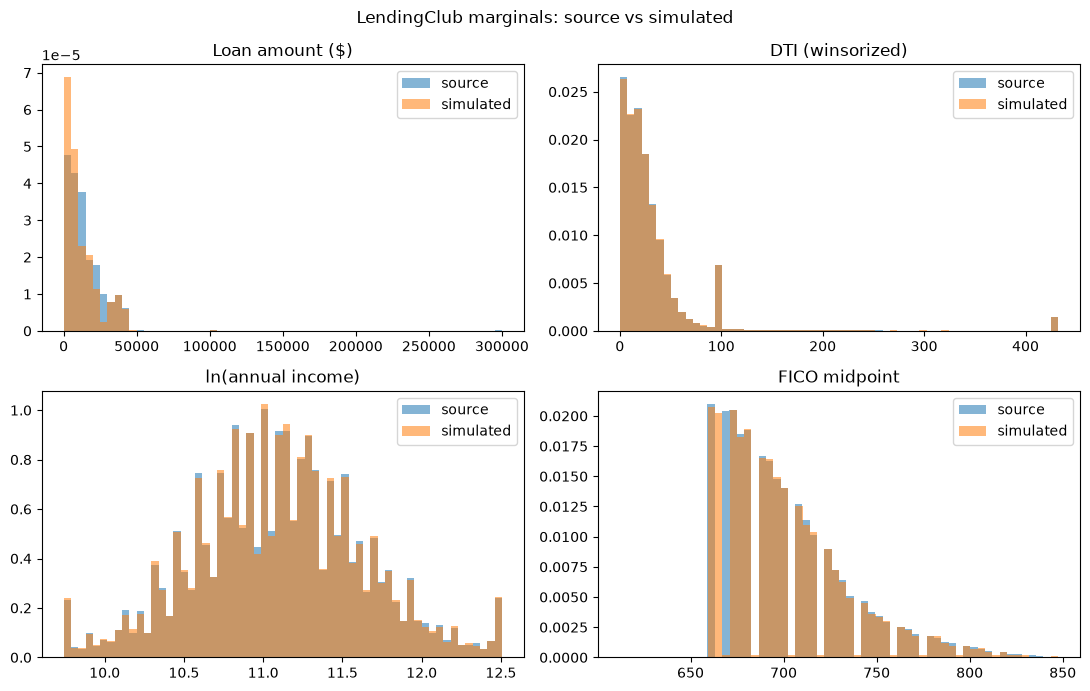

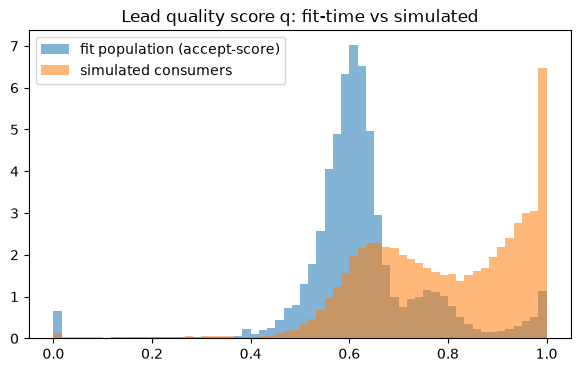

In [13]:
# Calibration exhibits: simulated-vs-source overlays (spec: side-by-side QA plots).
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
plots = [("loan_amnt", "Loan amount ($)", pool["loan_amnt"]),
         ("dti", "DTI (winsorized)", pool["dti"]),
         ("annual_inc_log", "ln(annual income)", acc["annual_inc_log"]),
         ("fico_mid", "FICO midpoint", acc["fico_mid"])]
for ax, (col, label, src) in zip(axes.ravel(), plots):
    ax.hist(src.dropna(), bins=60, density=True, alpha=0.55, label="source")
    ax.hist(sim[col], bins=60, density=True, alpha=0.55, label="simulated")
    ax.set_title(label); ax.legend()
fig.suptitle("LendingClub marginals: source vs simulated")
fig.tight_layout()
plt.show()

# Lead quality score q: simulated draws pushed through the stored model vs the fit-time histogram.
qs = P["quality_score"]
simx = pd.DataFrame({
    "log_amnt": np.log1p(sim["loan_amnt"]), "dti": sim["dti"],
    "emp_years_f": sim["emp_years"], "emp_missing": 0.0,
})[qs["features"]].to_numpy()
zsim = ((simx - np.array(qs["standardize_mean"])) / np.array(qs["standardize_std"]))            @ np.array(qs["coef"]) + qs["intercept"]
q_sim = np.clip((zsim - qs["rescale_bounds"][0]) /
                (qs["rescale_bounds"][1] - qs["rescale_bounds"][0]), 0, 1)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(q, bins=60, density=True, alpha=0.55, label="fit population (accept-score)")
ax.hist(q_sim, bins=60, density=True, alpha=0.55, label="simulated consumers")
ax.set_title("Lead quality score q: fit-time vs simulated"); ax.legend()
plt.show()


## 7. Result

`simulation/params/lendingclub_marginals.json` is written and round-trip verified: all KS,
categorical, and copula gates pass, and the simulated `q` distribution tracks the accept-score
shape. The simulated-consumer distributions above are the calibration exhibits for the site.

Next: `02_ipinyou.ipynb` — auction landscape (spec Section 2) → `auction_landscape.json`.
